### Pacotes importados

In [1]:
using LinearAlgebra
using Printf
using Plots

## Chapter 10: Newton's local method

### Algorithm 10.1: Newton's local method

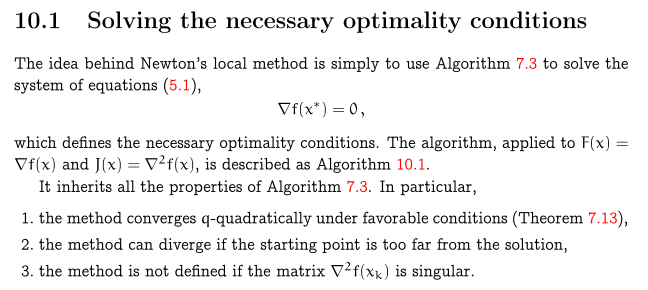

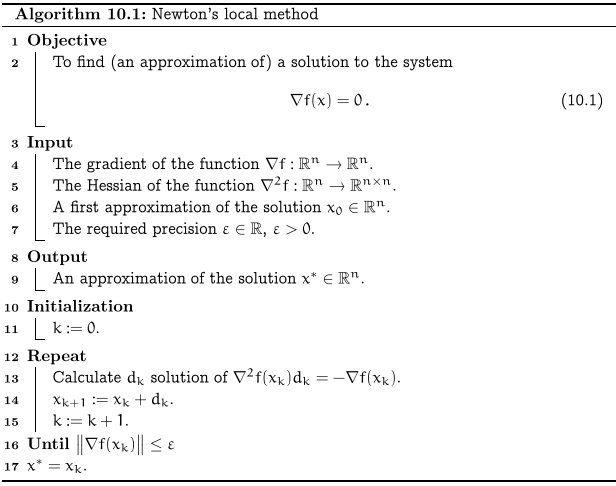

Example 5.8: $f(x_1,x_2) = \frac{1}{2} x_1^2 + x_1 \cos(x_2)$; $x_0 = [1.0, 1.0]$

In [2]:
function imprimir_historico(hist)
    println(" k |        f(x)        |    ||∇f(x)||    | x")
    println("-"^70)
    for h in hist
        @printf("%2d | %16.8e | %14.8e | %s\n",
                h.k, h.f, h.ng, string(round.(h.x, digits=6)))
    end
end

imprimir_historico (generic function with 1 method)

Status: convergiu
Solução aproximada x* = [1.990485074400243e-17, 1.5707963267948966]
f(x*) = 1.4169221291279266e-33
||∇f(x*)|| = 8.354308348422095e-17

 k |        f(x)        |    ||∇f(x)||    | x
----------------------------------------------------------------------
 0 |   1.04030231e+00 | 1.75516512e+00 | [1.0, 1.0]
 1 |  -2.06286156e-02 | 2.30665382e-01 | [-0.233845, 1.364192]
 2 |  -9.33543995e-05 | 1.12840545e-02 | [0.010814, 1.584836]
 3 |  -4.24133351e-12 | 2.32349802e-06 | [-2.0e-6, 1.570793]
 4 |   1.41692213e-33 | 8.35430835e-17 | [0.0, 1.570796]


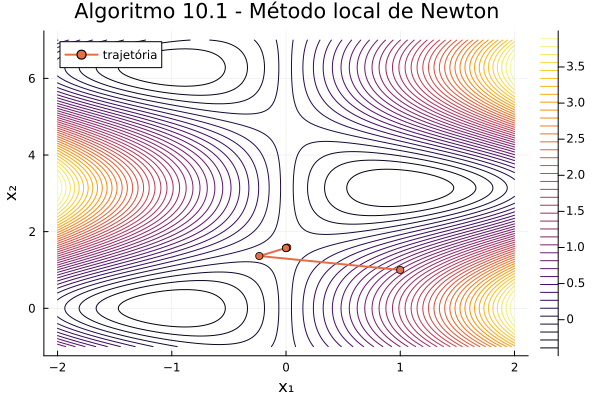

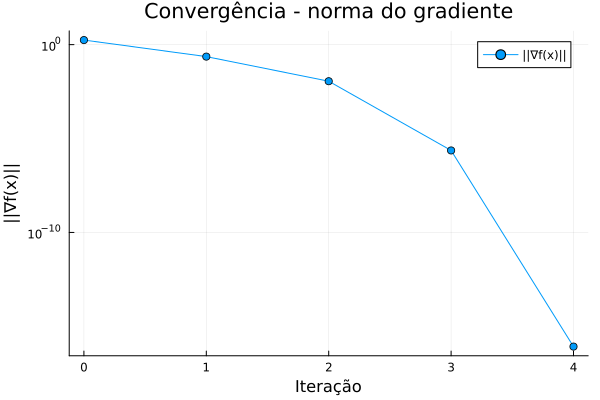

In [3]:
f_ex58(x) = 0.5*x[1]^2 + x[1]*cos(x[2])

function grad_ex58(x)
    return [x[1] + cos(x[2]);
            -x[1]*sin(x[2])]
end

function hess_ex58(x)
    return [1.0              -sin(x[2]);
            -sin(x[2])       -x[1]*cos(x[2])]
end

function newton_local(f, grad, hess, x0; ε=1e-8, kmax=50)
    x = copy(x0)
    hist = []

    for k in 0:kmax
        g = grad(x)
        H = hess(x)
        push!(hist, (k=k, x=copy(x), f=f(x), ng=norm(g)))

        if norm(g) <= ε
            return x, hist, :convergiu
        end

        
        d = -H \ g
        x = x + d
    end

    return x, hist, :max_iter
end

x0 = [1.0, 1.0]

x_star, hist_ex58, status_ex58 = newton_local(f_ex58, grad_ex58, hess_ex58, x0)

println("Status: ", status_ex58)
println("Solução aproximada x* = ", x_star)
println("f(x*) = ", f_ex58(x_star))
println("||∇f(x*)|| = ", norm(grad_ex58(x_star)))
println()
imprimir_historico(hist_ex58)


xs = range(-2.0, 2.0, length=200)
ys = range(-1.0, 7.0, length=200)
Z = [f_ex58([x,y]) for y in ys, x in xs]

traj_x = [h.x[1] for h in hist_ex58]
traj_y = [h.x[2] for h in hist_ex58]

p1 = contour(xs, ys, Z,
    levels=40,
    xlabel="x₁",
    ylabel="x₂",
    title="Algoritmo 10.1 - Método local de Newton",
    label="curvas de nível")

plot!(p1, traj_x, traj_y,
    marker=:circle,
    linewidth=2,
    label="trajetória")

display(p1)


p2 = plot([h.k for h in hist_ex58],
          [h.ng for h in hist_ex58],
          marker=:circle,
          yscale=:log10,
          xlabel="Iteração",
          ylabel="||∇f(x)||",
          title="Convergência - norma do gradiente",
          label="||∇f(x)||")

display(p2)

### Algorithm 10.2: Newton's local method by quadratic modeling

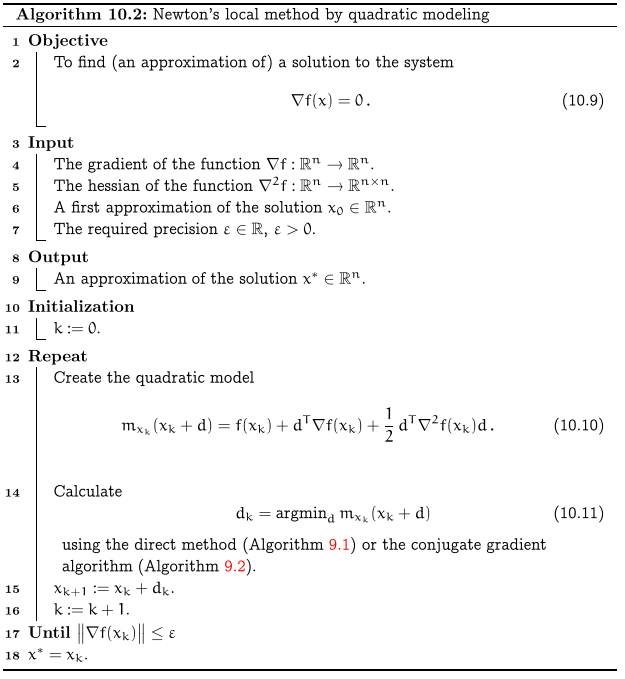

We test the algorithm on the Rosenbrock function. It is described in Section 11.6 of the book for two variables.  The implementation below involves $n$ variables: \\[f(x) = \sum_{i=1}^{n-1} f_i(x) = \sum_{i=1}^{n-1} 100 (x_{i+1}-x_i^2)^2 + (1-x_i)^2.\\]
The calculation of the derivatives is based on the partial derivatives of the functions $f_i$:
\\[
\begin{array}{rcl}
\partial f_i/\partial x_i&=& -400 x_i (x_{i+1}-x_i^2) - 2(1-x_i), \\\\
\partial f_i/\partial x_{i+1}&=& 200 (x_{i+1}-x_i^2), \\\\
\partial^2 f_i/\partial x^2_i  &=& -400 x_{i+1}+ 1200 x_i^2 + 2, \\\\
\partial^2 f_i/\partial x_i \partial x_{i+1}  &=& -400 x_i^2, \\\\
\partial^2 f_i/\partial x^2_{i+1}  &=& 200. 
\end{array}
\\]

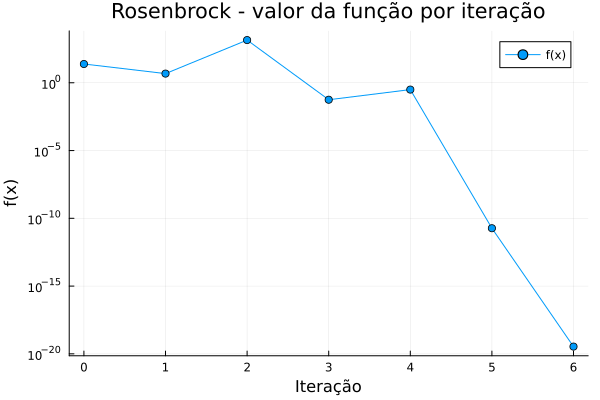

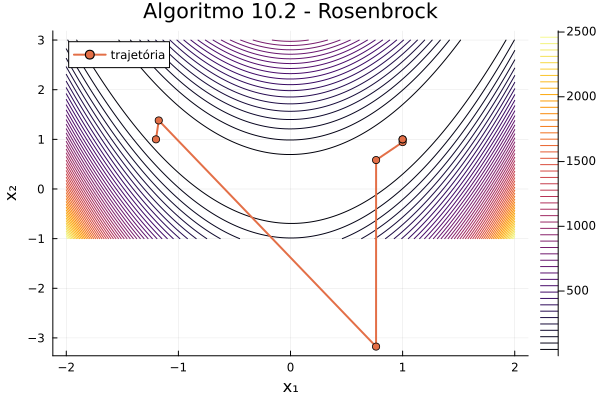

Status: convergiu
Solução aproximada x* = [0.9999999999999999, 0.9999999999814724]
f(x*) = 3.4326461875363225e-20
||∇f(x*)|| = 8.285705791275366e-9

 k |        f(x)        |    ||∇f(x)||    | x
----------------------------------------------------------------------
 0 |   2.42000000e+01 | 2.32867688e+02 | [-1.2, 1.0]
 1 |   4.73188433e+00 | 4.63942621e+00 | [-1.175281, 1.380674]
 2 |   1.41184518e+03 | 1.37078985e+03 | [0.763115, -3.175034]
 3 |   5.59655168e-02 | 4.73110379e-01 | [0.76343, 0.582825]
 4 |   3.13189076e-01 | 2.50274456e+01 | [0.999995, 0.944027]
 5 |   1.85273974e-11 | 8.60863352e-06 | [0.999996, 0.999991]
 6 |   3.43264619e-20 | 8.28570579e-09 | [1.0, 1.0]


In [4]:
function rosenbrock(x)
    n = length(x)
    soma = 0.0
    for i in 1:n-1
        soma += 100.0*(x[i+1] - x[i]^2)^2 + (1.0 - x[i])^2
    end
    return soma
end

function grad_rosenbrock(x)
    n = length(x)
    g = zeros(n)

    for i in 1:n-1
        g[i]   += -400.0*x[i]*(x[i+1] - x[i]^2) - 2.0*(1.0 - x[i])
        g[i+1] +=  200.0*(x[i+1] - x[i]^2)
    end

    return g
end

function hess_rosenbrock(x)
    n = length(x)
    H = zeros(n,n)

    for i in 1:n-1
        H[i,i]     += -400.0*x[i+1] + 1200.0*x[i]^2 + 2.0
        H[i,i+1]   += -400.0*x[i]
        H[i+1,i]   += -400.0*x[i]
        H[i+1,i+1] += 200.0
    end

    return H
end


function resolver_quadratico_direto(g, H)
    
    F = cholesky(Symmetric(H))
    return -(F \ g)
end


function resolver_quadratico_cg(g, H; tol=1e-10, kmax=1000)
    n = length(g)
    d = zeros(n)
    r = -g - H*d
    p = copy(r)
    rsold = dot(r,r)

    for k in 1:kmax
        Hp = H*p
        α = rsold / dot(p, Hp)
        d = d + α*p
        r = r - α*Hp
        rsnew = dot(r,r)

        if sqrt(rsnew) < tol
            return d
        end

        p = r + (rsnew/rsold)*p
        rsold = rsnew
    end

    return d
end

function newton_quadratic_model(f, grad, hess, x0; ε=1e-8, kmax=50, metodo=:direto)
    x = copy(x0)
    hist = []

    for k in 0:kmax
        g = grad(x)
        H = hess(x)
        push!(hist, (k=k, x=copy(x), f=f(x), ng=norm(g)))

        if norm(g) <= ε
            return x, hist, :convergiu
        end

        d = if metodo == :direto
            resolver_quadratico_direto(g, H)
        elseif metodo == :cg
            
            cholesky(Symmetric(H))
            resolver_quadratico_cg(g, H)
        else
            error("Método desconhecido. Use :direto ou :cg.")
        end

        x = x + d
    end

    return x, hist, :max_iter
end


n = 2
x0_rosen = [-1.2, 1.0]

x_rosen, hist_rosen, status_rosen = newton_quadratic_model(
    rosenbrock,
    grad_rosenbrock,
    hess_rosenbrock,
    x0_rosen;
    ε=1e-8,
    kmax=50,
    metodo=:direto
)

println("Status: ", status_rosen)
println("Solução aproximada x* = ", x_rosen)
println("f(x*) = ", rosenbrock(x_rosen))
println("||∇f(x*)|| = ", norm(grad_rosenbrock(x_rosen)))
println()
imprimir_historico(hist_rosen)


p3 = plot([h.k for h in hist_rosen],
          [h.f for h in hist_rosen],
          marker=:circle,
          yscale=:log10,
          xlabel="Iteração",
          ylabel="f(x)",
          title="Rosenbrock - valor da função por iteração",
          label="f(x)")

display(p3)


xs = range(-2.0, 2.0, length=250)
ys = range(-1.0, 3.0, length=250)
Z = [rosenbrock([x,y]) for y in ys, x in xs]

traj_x_rosen = [h.x[1] for h in hist_rosen]
traj_y_rosen = [h.x[2] for h in hist_rosen]

p4 = contour(xs, ys, Z,
    levels=50,
    xlabel="x₁",
    ylabel="x₂",
    title="Algoritmo 10.2 - Rosenbrock",
    label="curvas de nível")

plot!(p4, traj_x_rosen, traj_y_rosen,
    marker=:circle,
    linewidth=2,
    label="trajetória")

display(p4)

We now apply the algorithm on example 5.8. In this case, the algorithm fails to converge, and one hessian is not positive definite. We try first using the direct method to solve the quadratic problem. An error is triggered. 

In [5]:
try
    x_fail_direto, hist_fail_direto, status_fail_direto = newton_quadratic_model(
        f_ex58,
        grad_ex58,
        hess_ex58,
        x0;
        ε=1e-8,
        kmax=20,
        metodo=:direto
    )

    println("Status: ", status_fail_direto)
    println("x = ", x_fail_direto)

catch erro
    println("Erro acionado no método direto:")
    println(erro)
    println()
    println("Interpretação: a Hessiana não é definida positiva em alguma iteração,")
    println("logo o modelo quadrático não possui mínimo local bem definido pelo método direto.")
end

Erro acionado no método direto:
PosDefException(2)

Interpretação: a Hessiana não é definida positiva em alguma iteração,
logo o modelo quadrático não possui mínimo local bem definido pelo método direto.


If we try with the conjugate gradient method, an error is also triggered. 

In [6]:
try
    x_fail_cg, hist_fail_cg, status_fail_cg = newton_quadratic_model(
        f_ex58,
        grad_ex58,
        hess_ex58,
        x0;
        ε=1e-8,
        kmax=20,
        metodo=:cg
    )

    println("Status: ", status_fail_cg)
    println("x = ", x_fail_cg)

catch erro
    println("Erro acionado no método do gradiente conjugado:")
    println(erro)
    println()
    println("Interpretação: como a Hessiana não é definida positiva,")
    println("o gradiente conjugado não é adequado para este subproblema quadrático.")
end

Erro acionado no método do gradiente conjugado:
PosDefException(2)

Interpretação: como a Hessiana não é definida positiva,
o gradiente conjugado não é adequado para este subproblema quadrático.
